In [102]:
from pathlib import Path
from typing import List, Sequence, Optional, Any, Tuple
from plotnine import (
	ggplot,
	aes,
	geom_line,
	geom_point,
	ggtitle,
	xlab,
	ylab,
	theme,
	element_text,
	element_rect,
 	element_line
)
from plotnine.themes import theme_classic
import plotnine.scales as scales
import polars as pl
import pandas as pd


In [62]:
# --- Load Excel file ---
def load_file(file_name: str, sheet_name= None) -> pl.DataFrame:
    
    """Load an Excel file as a DataFrame with a fast engine for processing Excel files.
    Parameters:
    - file_name
    - sheet_name: Excel sheet required or None to load the first sheet
    Returns a pandas DataFrame"""
    
    # 1. Get the folder where THIS script lives
    script_location = Path.cwd()
    
    # 2. Build the path to the file relative to the script
    file_path = script_location / "Data" / file_name
    
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {file_path}')
    # Let pandas choose a working engine (openpyxl, xlrd, etc.). If your environment requires a specific engine, pass it here.    
    return pl.read_excel(path, sheet_name=sheet_name, engine="calamine")

In [25]:
# Example:
df = load_file("Moha_NMC_200_73_Channel_12_Wb_1.xlsx", "Channel-12_1")
df.head()

Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 17, falling back to string


Data_Point,Date_Time,Test_Time(s),Step_Time(s),time(h),Cycle_Index,Step_Index,Current(A),Specific Capacity (mAh/g),Voltage(V),Power(W),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),ACR(Ohm),dV/dt(V/s),Internal_Resistance(Ohm),dQ/dV(Ah/V),Specific dQ/dV,dV/dQ(V/Ah)
i64,datetime[ms],f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64
1,2025-09-17 18:24:13.862,60.0008,60.0007,0.016667,1,1,0.0,0.0,2.6216,0.0,0.0,0.0,0.0,0.0,null,-0.000035,null,null,0.0,null
2,2025-09-17 18:25:13.862,120.0006,120.0005,0.033333,1,1,0.0,0.0,2.6211,0.0,0.0,0.0,0.0,0.0,null,0.000012,null,null,0.0,null
3,2025-09-17 18:26:13.862,180.0005,180.0004,0.05,1,1,0.0,0.0,2.6203,0.0,0.0,0.0,0.0,0.0,null,-0.000038,null,0.0,0.0,0.0
4,2025-09-17 18:27:13.862,240.0003,240.0002,0.066667,1,1,0.0,0.0,2.6158,0.0,0.0,0.0,0.0,0.0,null,-0.000063,null,null,0.0,null
5,2025-09-17 18:28:13.863,300.001,300.0009,0.083334,1,1,0.0,0.0,2.6089,0.0,0.0,0.0,0.0,0.0,null,-0.000103,null,0.0,0.0,0.0


In [26]:
# --- Filtering function ---
def filtering(df: pl.DataFrame, filter_column_names: Sequence[str], ranges: Sequence[Sequence[Any]]) -> pl.DataFrame:
    """Filter `df` by multiple columns using membership tests (isin).
    - `filter_column_names`: sequence of column names to filter on
    - `ranges`: sequence of sequences containing allowed values for each corresponding column
    Returns the filtered DataFrame."""
    if len(filter_column_names) != len(ranges):
        raise ValueError('filter_column_names and ranges must have the same length')
    
    filtered_df = df.clone()
    
    for col, allowed in zip(filter_column_names, ranges):
        if col not in filtered_df.columns:
            raise KeyError(f"Column '{col}' not found in DataFrame")
        
        filtered_df = filtered_df.filter(filtered_df[col].is_in(allowed))
        
    return filtered_df

In [115]:
def plotnine_ploting(
    df: pl.DataFrame,
    multiple_graphs: bool = True,
    show_legend: bool = True,
    points_and_lines: int = 1,
    column_filter: Optional[str] = 'Cycle_Index',
    column_x: str = 'Cycle_Index',
    column_y: str = 'Specific Capacity (mAh/g)',
    plot_title: str = 'Plot',
    folder_name: str = 'default',
    markevery: int = 1,
    save_base: str = 'Cycling/plots',
    overwrite: bool = False,
    dpi: int = 400,
    width: float = 8,
    height: float = 6,
    units: str = 'in')-> Tuple[str, str]:
    
    # Convert to pandas for plotnine
    df = pd.DataFrame(df.to_pandas())
    
    # Determine if grouping should be applied
    use_grouping = column_filter in df.columns if column_filter else False
    
    # Prepare grouping column if present
    if use_grouping:
        df[column_filter] = df[column_filter].astype('category')

    # Build ggplot using aes_string for dynamic column names
    # Base ggplot mapping
    aes_mapping = dict(x=column_x, y=column_y)
    
    if multiple_graphs and use_grouping:
        aes_mapping.update(color=column_filter, group=column_filter)
    gg = ggplot(df, aes(**aes_mapping))

    # Sample points for markers
    if markevery > 1:
        if multiple_graphs and use_grouping:
            point_df = (df.assign(_idx=df.groupby(column_filter, observed=True).cumcount()).loc[lambda d: d["_idx"] % markevery == 0].drop(columns="_idx"))
        else:
            point_df = df.iloc[::markevery].copy()
    else:
        point_df = df.copy()

    # Define layers
    layers = []
    if points_and_lines in [0, 2]:
        layers.append(geom_line(size=0.8))  # Slightly thicker line for publications
    if points_and_lines in [1, 2]:
        layers.append(geom_point(data=point_df, size=4, stroke=0.5))  # Larger points for visibility
    for layer in layers:
        gg = gg + layer

    # Colormap for multiple graphs
    if multiple_graphs and use_grouping:
        gg = gg + scales.scale_colour_discrete()


    gg = (gg + ggtitle(plot_title)
          + xlab(column_x)
          + ylab(column_y)
          + theme_classic(base_size=12)
          + theme(                  
                axis_text=element_text(size=12),
                axis_title=element_text(size=12),
                plot_title=element_text(size=12, weight='bold'),
                legend_position='right' if show_legend else 'none',
                panel_background=element_rect(fill='lightgray'),
                panel_border=element_rect(color='black', size=1.5),
                figure_size=(width, height),
                panel_grid_major=element_line(color="white", size=0.7),
                panel_grid_minor=element_line(color="white", size=0.25),
         ))

    if not show_legend:
        gg = gg + theme(legend_position='none')
    
    gg.show()
    # Prepare save paths
    save_folder = Path(save_base) / folder_name
    save_folder.mkdir(parents=True, exist_ok=True)
    safe_title = plot_title.replace(' ', '_').replace('/', '_')
    save_paths = {
        'PNG': save_folder / f"{safe_title}.png",
        'PDF': save_folder / f"{safe_title}.pdf"
    }

    # Save files
    for fmt, path in save_paths.items():
        if path.exists() and not overwrite:
            print(f"Skipping existing {fmt} (overwrite=False): {path}")
        else:
            gg.save(str(path), dpi=dpi if fmt == 'PNG' else None, width=width, height=height, units=units)
            print(f"{fmt} saved to {path}")

    return str(save_paths['PNG']), str(save_paths['PDF'])

In [121]:
def build_selected_cycles(df: pl.DataFrame, start: Tuple[int, int], mid: int, end: Tuple[int, int]) -> List[int]:
    cycles = sorted(df['Cycle_Index'].unique())
    return sorted(set(cycles[start[0]:start[1]] + [c for c in cycles if c % mid == 0] + cycles[end[0]:end[1]]))

Selected cycles: [1, 2, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 51, 52]


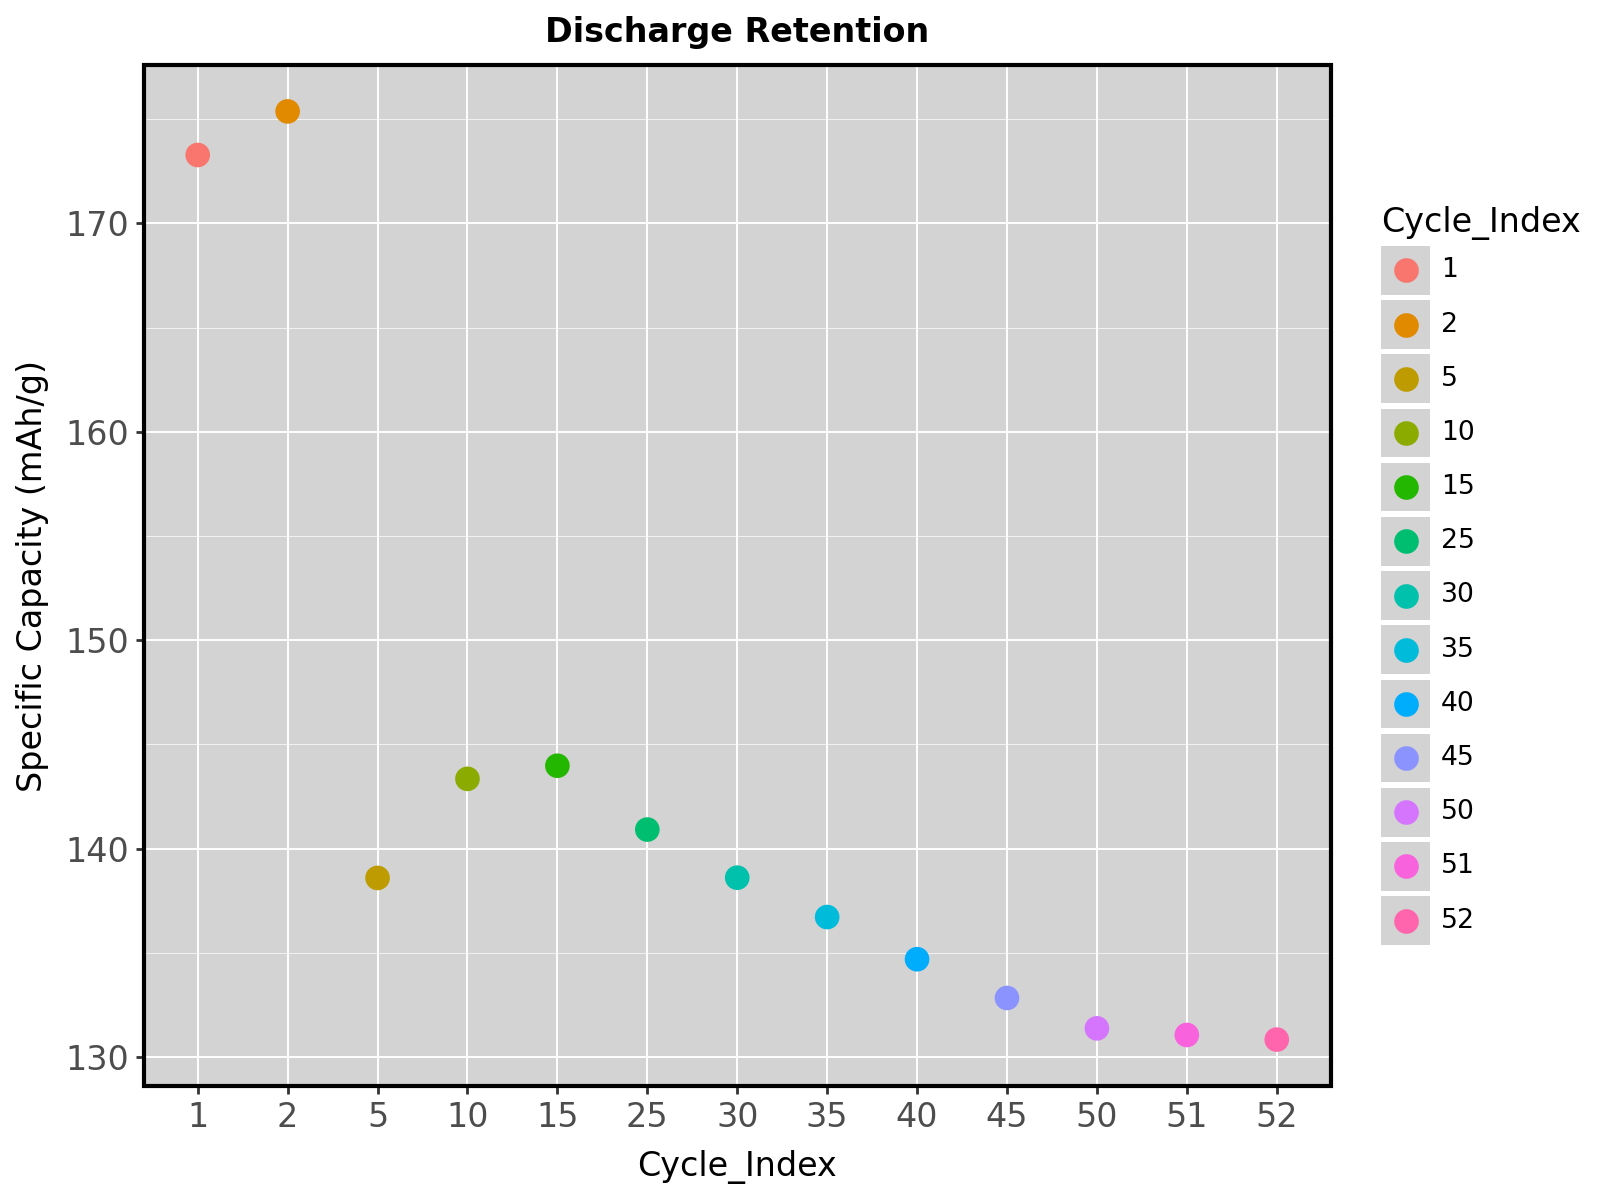

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\NMC_200_73\Discharge_Retention.png


PNG saved to Cycling\plots\NMC_200_73\Discharge_Retention.png
PDF saved to Cycling\plots\NMC_200_73\Discharge_Retention.pdf


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\NMC_200_73\Discharge_Retention.pdf


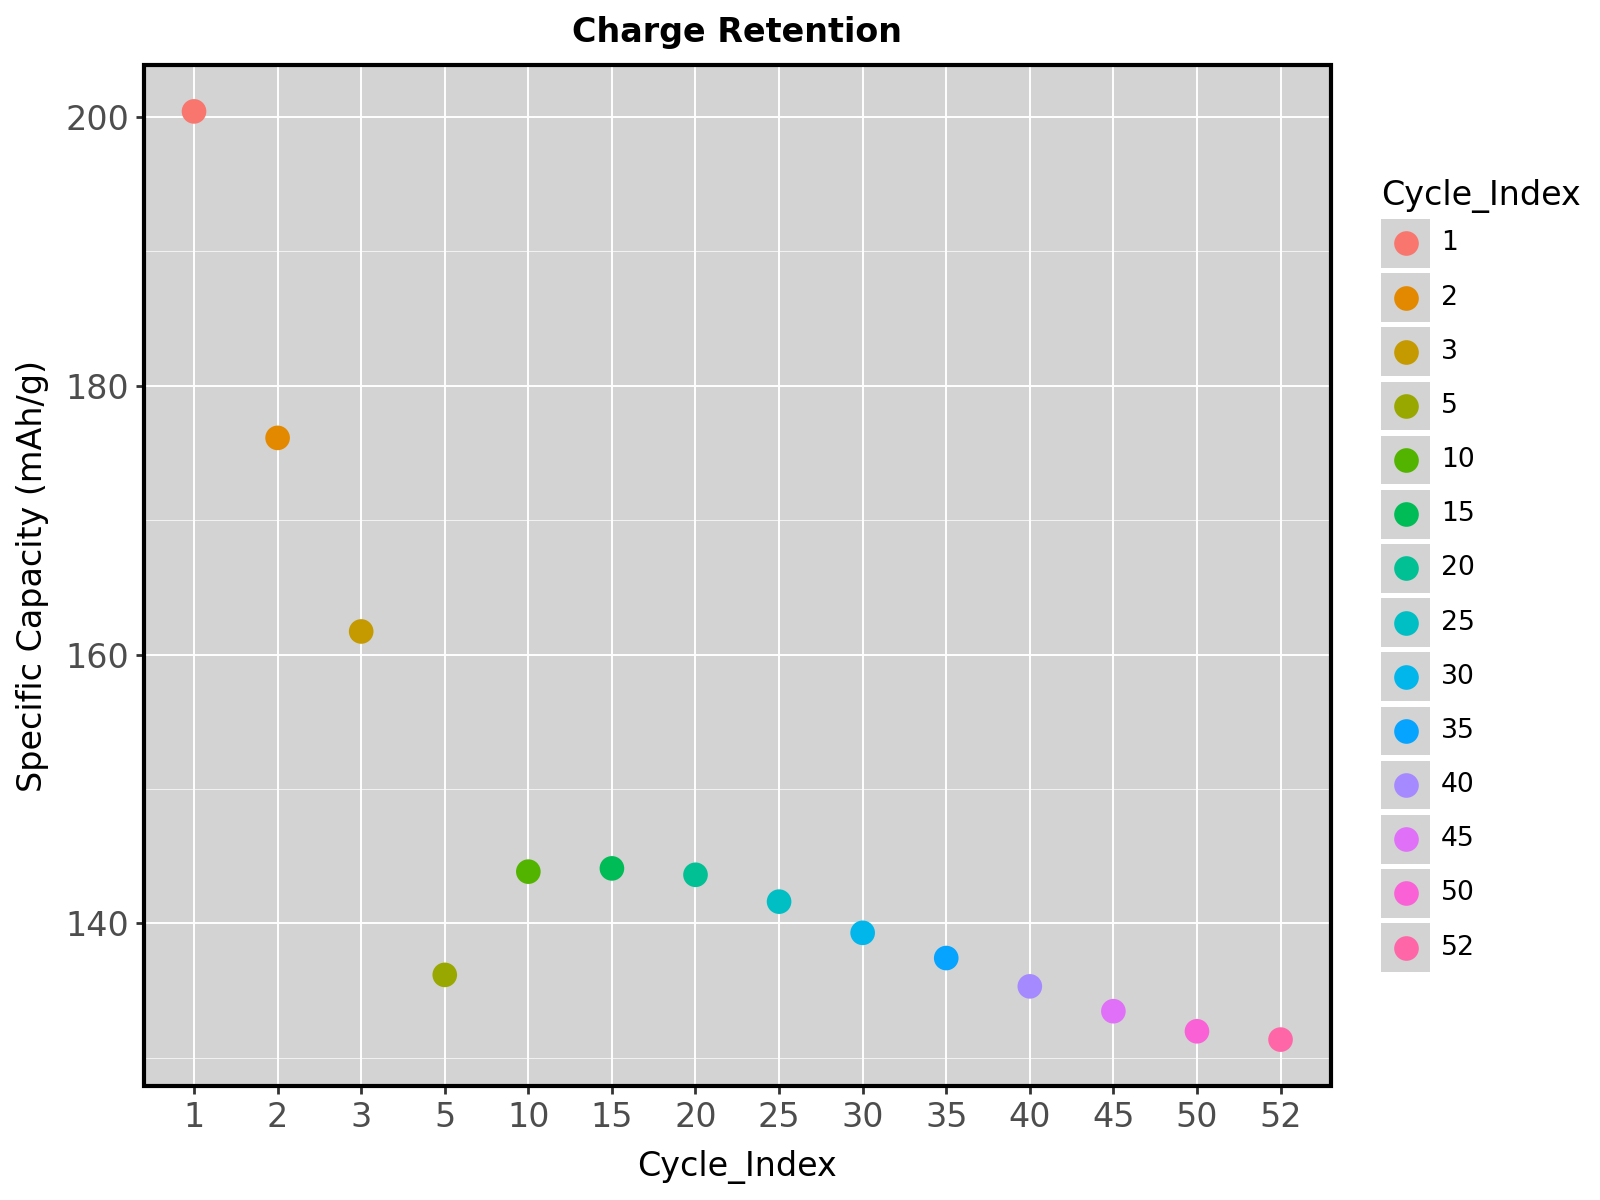

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\NMC_200_73\Charge_Retention.png


PNG saved to Cycling\plots\NMC_200_73\Charge_Retention.png
PDF saved to Cycling\plots\NMC_200_73\Charge_Retention.pdf


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\NMC_200_73\Charge_Retention.pdf


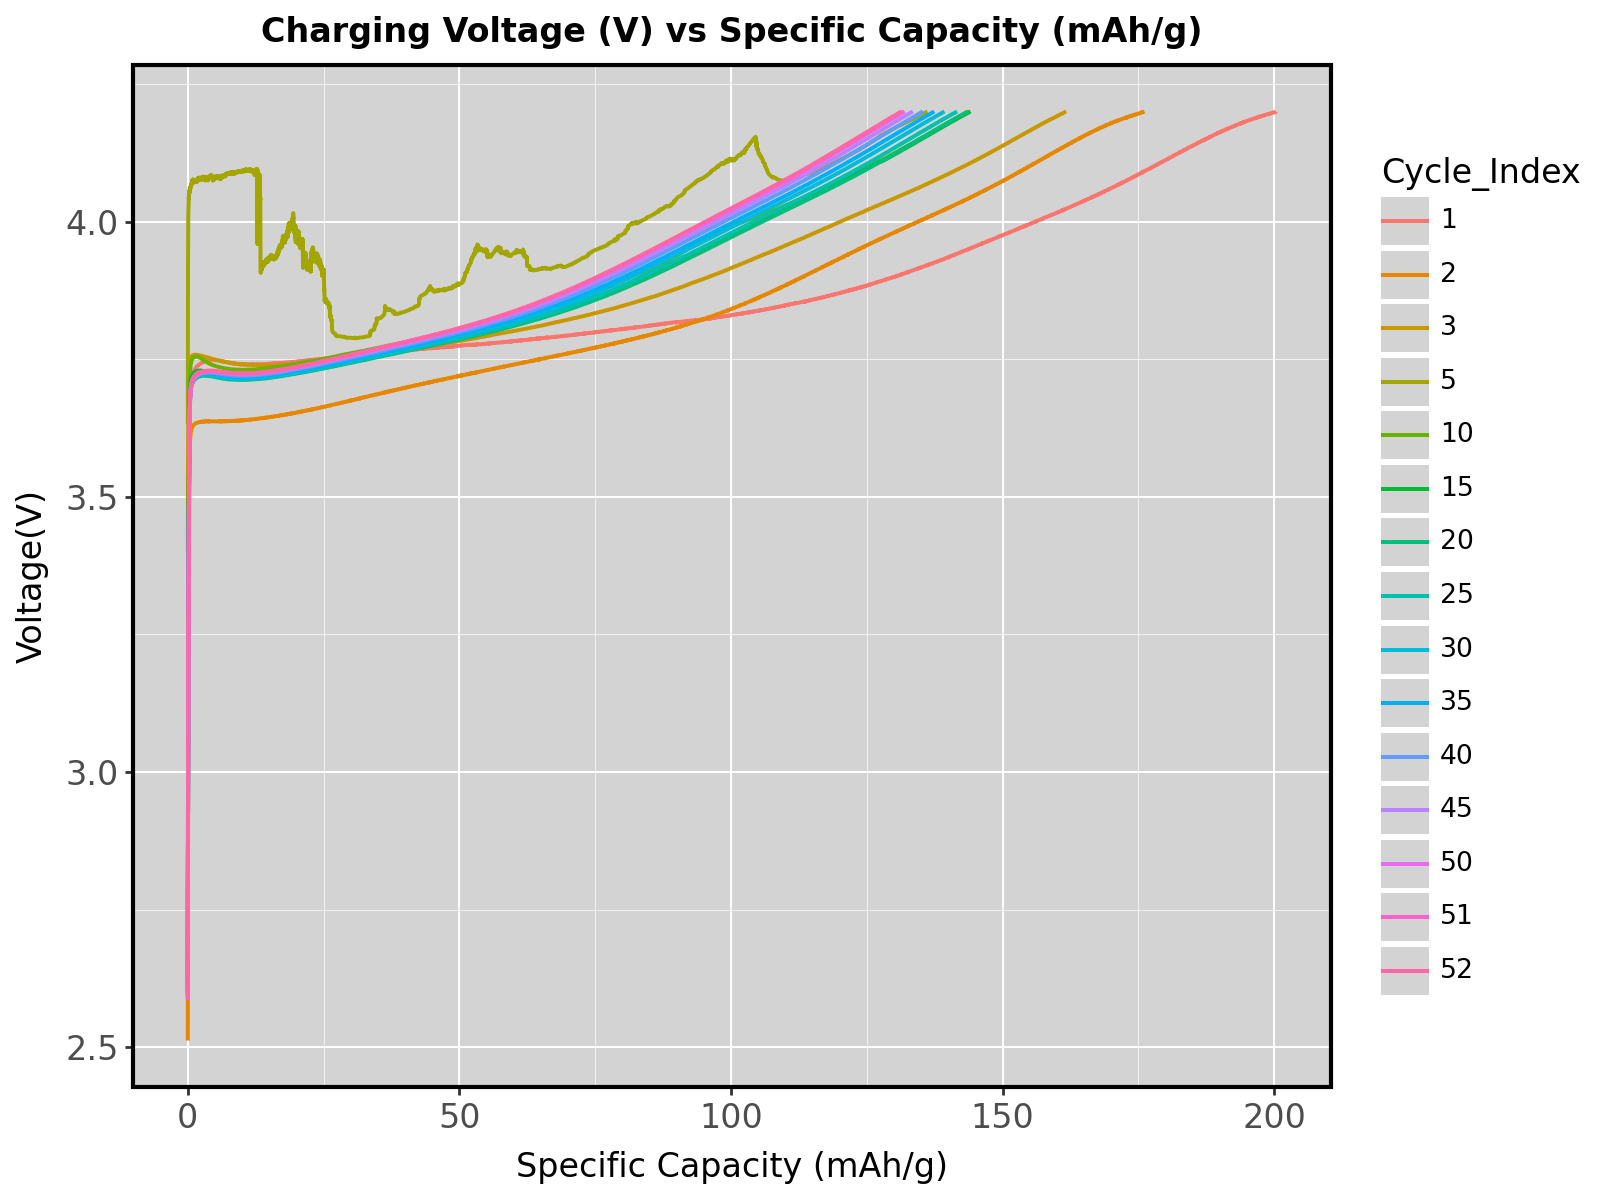

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\NMC_200_73\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


PNG saved to Cycling\plots\NMC_200_73\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\NMC_200_73\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


PDF saved to Cycling\plots\NMC_200_73\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


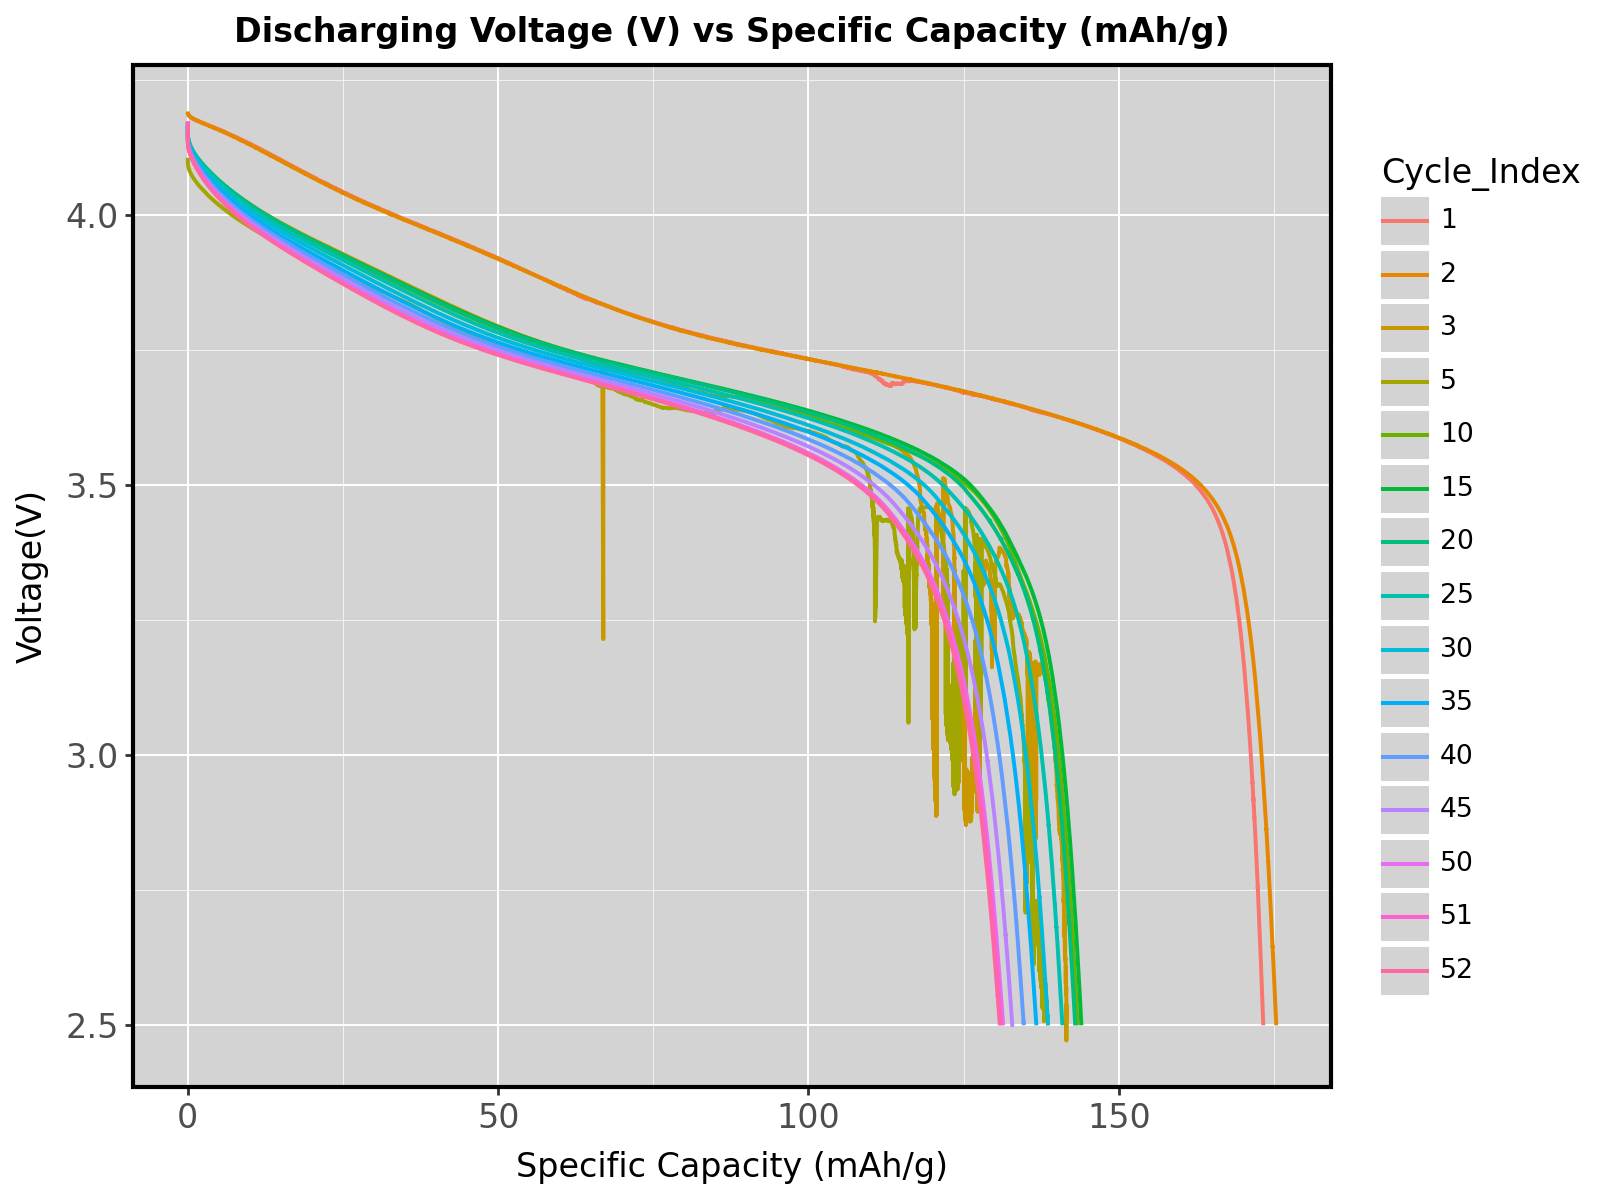

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\NMC_200_73\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


PNG saved to Cycling\plots\NMC_200_73\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\NMC_200_73\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


PDF saved to Cycling\plots\NMC_200_73\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


('Cycling\\plots\\NMC_200_73\\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png',
 'Cycling\\plots\\NMC_200_73\\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf')

In [ ]:
#df = load_file(r'C:/Users/MTP24ME/Documents/CODE_PHD/meizeddin_PhD_code/Cycling/Data/Moha_NMC_200_73_Channel_12_Wb_1.xlsx', 'Channel-12_1')
selected_cycles = build_selected_cycles(df, start=(0, 3), mid=5, end=(-3, -1))
print('Selected cycles:', selected_cycles)

# 1. Discharge retention (example)
filtered_df = filtering(df, ['Step_Index', 'Voltage(V)', 'Cycle_Index'], [[3, 7], [2.5], selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=1, column_filter='Cycle_Index', 
                 column_x='Cycle_Index', column_y='Specific Capacity (mAh/g)', 
                 plot_title='Discharge Retention', folder_name='NMC_200_73', 
                 markevery=20, save_base='Cycling/plots', overwrite=True)

# 2. Charge retention (example)
filtered_df = filtering(df, ['Step_Index', 'Voltage(V)', 'Cycle_Index'], [[2, 6], [4.2], selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=1, column_filter='Cycle_Index', 
                 column_x='Cycle_Index', column_y='Specific Capacity (mAh/g)', 
                 plot_title='Charge Retention', folder_name='NMC_200_73', 
                 markevery=20,save_base='Cycling/plots', overwrite=True)
# 3. Charging Voltage vs Specific Capacity
filtered_df = filtering(df, ['Step_Index', 'Cycle_Index'], [[2, 6], selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=0, column_filter='Cycle_Index', 
                 column_x='Specific Capacity (mAh/g)', column_y='Voltage(V)', 
                 plot_title='Charging Voltage (V) vs Specific Capacity (mAh/g)', 
                 folder_name='NMC_200_73', markevery=20, save_base='Cycling/plots', overwrite=True)

# 4. Discharging Voltage vs Specific Capacity
filtered_df = filtering(df, ['Step_Index', 'Cycle_Index'], [[3, 7], selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=0, column_filter='Cycle_Index', 
                 column_x='Specific Capacity (mAh/g)', column_y='Voltage(V)', 
                 plot_title='Discharging Voltage (V) vs Specific Capacity (mAh/g)', 
                 folder_name='NMC_200_73', markevery=20, save_base='Cycling/plots', overwrite=True)